C:\Anaconda3\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


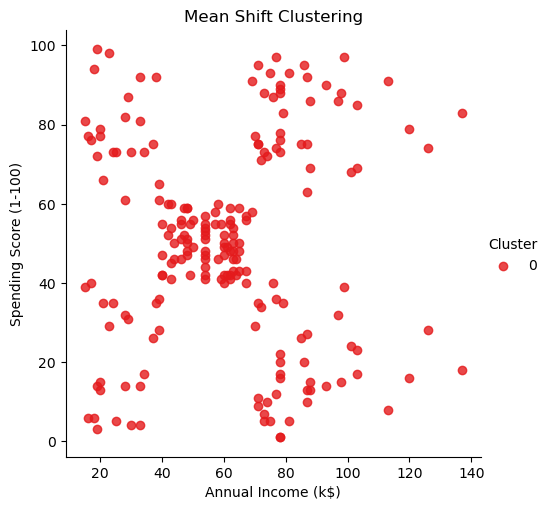

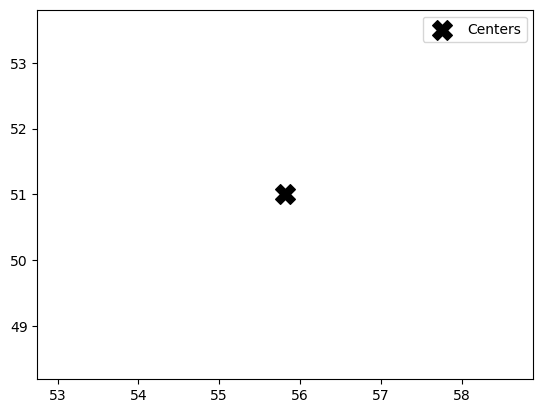

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift

# Load dataset
dataset = pd.read_csv("Mall_Customers.csv")

# Select features (Annual Income and Spending Score)
X = dataset.iloc[:, [3, 4]].values

# Apply Mean Shift
ms = MeanShift()
y_ms = ms.fit_predict(X)

# Add cluster labels to the dataset
dataset["Cluster"] = y_ms

# Visualize clusters with lmplot
facet = sns.lmplot(
    data=dataset,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    fit_reg=False,
    legend_out=True,
    palette="Set1"
)

plt.title("Mean Shift Clustering")
plt.show()

# Plot cluster centers separately (optional)
centers = ms.cluster_centers_
plt.scatter(
    centers[:,0], centers[:,1],
    c="black", s=200, marker="X", label="Centers"
)
plt.legend()
plt.show()